In [9]:
!pip install -q transformers datasets seqeval evaluate accelerate

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          TrainingArguments, Trainer, DataCollatorForTokenClassification)
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [11]:
import json, re
from collections import Counter
from datasets import Dataset, DatasetDict, Features, Sequence, ClassLabel, Value

# ---- Load the raw Kaggle JSON ----
raw_data = []

with open("/content/Entity Recognition in Resumes.json", "r") as f:
    for line in f:
        line = line.strip()

        if line:
            raw_data.append(json.loads(line))

print(f"Loaded {len(raw_data)} resumes")

# ---- All entity labels ----
LABELS = [
    "O",
    "B-Name",                    "I-Name",
    "B-Skills",                  "I-Skills",
    "B-College_Name",            "I-College_Name",
    "B-Degree",                  "I-Degree",
    "B-Designation",             "I-Designation",
    "B-Companies_worked_at",     "I-Companies_worked_at",
    "B-Email_Address",           "I-Email_Address",
    "B-Location",                "I-Location",
    "B-Links",                   "I-Links",
    "B-Graduation_Year",         "I-Graduation_Year",
    "B-Years_of_Experience",     "I-Years_of_Experience",
    "B-Certifications",          "I-Certifications",
    "B-Awards",                  "I-Awards",
]

label2id = {l: i for i, l in enumerate(LABELS)}

# ---- Convert annotations to BIO tags ----
def convert_to_bio(item):

    text = item["content"]
    annotations = item.get("annotation", [])

    words = []
    spans = []

    # tokenize by whitespace
    for match in re.finditer(r"\S+", text):
        words.append(match.group())
        spans.append((match.start(), match.end()))

    labels = ["O"] * len(words)

    # apply entity labels
    for ann in annotations:

        if "label" not in ann or "points" not in ann:
            continue

        if not ann["label"]:
            continue

        entity = ann["label"][0]

        for point in ann["points"]:

            start = point["start"]
            end = point["end"]

            first = True

            for idx, (s, e) in enumerate(spans):

                overlap = max(0, min(e, end + 1) - max(s, start))

                if overlap > 0:

                    if first:
                        labels[idx] = f"B-{entity}"
                        first = False
                    else:
                        labels[idx] = f"I-{entity}"

    final_labels = [
        label2id[l] if l in label2id else label2id["O"]
        for l in labels
    ]

    return {
        "tokens": words,
        "ner_tags": final_labels
    }

# ---- Build converted dataset ----
converted = [convert_to_bio(item) for item in raw_data]

# remove empty samples
converted = [s for s in converted if len(s["tokens"]) > 0]

# ---- DEBUG: inspect first sample ----
print("\nFIRST SAMPLE TOKENS:\n")
print(converted[0]["tokens"][:40])

print("\nFIRST SAMPLE LABELS:\n")
print([LABELS[x] for x in converted[0]["ner_tags"][:40]])

# ---- DEBUG: label distribution ----
print("\nLABEL DISTRIBUTION:\n")

counter = Counter()

for sample in converted:
    counter.update(sample["ner_tags"])

for k, v in counter.items():
    print(f"{LABELS[k]} : {v}")

# ---- HuggingFace dataset ----
features = Features({
    "tokens":   Sequence(Value("string")),
    "ner_tags": Sequence(ClassLabel(names=LABELS))
})

def to_hf(samples):
    return Dataset.from_dict(
        {
            "tokens": [s["tokens"] for s in samples],
            "ner_tags": [s["ner_tags"] for s in samples]
        },
        features=features
    )

import random

random.seed(42)
random.shuffle(converted)

n = len(converted)

train_end = int(0.8 * n)
val_end   = int(0.9 * n)

dataset = DatasetDict({
    "train": to_hf(converted[:train_end]),
    "validation": to_hf(converted[train_end:val_end]),
    "test": to_hf(converted[val_end:])
})

print(dataset)

Loaded 220 resumes

FIRST SAMPLE TOKENS:

['Abhishek', 'Jha', 'Application', 'Development', 'Associate', '-', 'Accenture', 'Bengaluru,', 'Karnataka', '-', 'Email', 'me', 'on', 'Indeed:', 'indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a', '•', 'To', 'work', 'for', 'an', 'organization', 'which', 'provides', 'me', 'the', 'opportunity', 'to', 'improve', 'my', 'skills', 'and', 'knowledge', 'for', 'my', 'individual', 'and', "company's", 'growth', 'in', 'best']

FIRST SAMPLE LABELS:

['B-Name', 'I-Name', 'B-Designation', 'I-Designation', 'I-Designation', 'O', 'O', 'B-Location', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

LABEL DISTRIBUTION:

B-Name : 223
I-Name : 236
B-Designation : 501
I-Designation : 876
O : 102798
B-Location : 419
B-Skills : 451
I-Skills : 7275
B-Degree : 296
I-Degree : 821
I-Location : 29
DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'

In [12]:
model_checkpoint = "dslim/bert-base-NER"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
    examples["tokens"],
    truncation=True,
    padding="max_length",
    max_length=256,
    is_split_into_words=True
)
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev:
                label_ids.append(label[wid])
            else:
                label_ids.append(-100)   # only label first sub-token of a word
            prev = wid
        labels.append(label_ids)
    tokenized["labels"] = labels
    return tokenized

tokenized_ds = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

In [15]:
label_list = LABELS
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label={i: l for i, l in enumerate(label_list)},
    label2id={l: i for i, l in enumerate(label_list)},
    ignore_mismatched_sizes=True
)

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    preds, labels = p
    preds = np.argmax(preds, axis=2)
    true_preds = [[label_list[pr] for pr, l in zip(pred, lab) if l != -100]
                  for pred, lab in zip(preds, labels)]
    true_labels = [[label_list[l] for pr, l in zip(pred, lab) if l != -100]
                   for pred, lab in zip(preds, labels)]
    results = seqeval.compute(predictions=true_preds, references=true_labels)
    return {"precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"]}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |                                                                                      
-------------------------+------------+--------------------------------------------------------------------------------------
bert.pooler.dense.weight | UNEXPECTED |                                                                                      
bert.pooler.dense.bias   | UNEXPECTED |                                                                                      
classifier.weight        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9, 768]) vs model:torch.Size([27, 768])
classifier.bias          | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9]) vs model:torch.Size([27])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not mat

In [16]:
args = TrainingArguments(
    output_dir="resume-ner-model",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=40,
    weight_decay=0.01,
    report_to="none",
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.494481,0.585173,0.000000,0.000000,0.000000,0.915243
2,0.552571,0.301697,0.121212,0.044444,0.065041,0.933356
3,0.346710,0.185374,0.558824,0.422222,0.481013,0.956596
4,0.264082,0.168343,0.635135,0.522222,0.573171,0.960355
5,0.195058,0.133286,0.612903,0.633333,0.622951,0.966165
6,0.138776,0.123175,0.623762,0.700000,0.659686,0.968558
7,0.113633,0.128345,0.666667,0.711111,0.688172,0.968558
8,0.086738,0.124117,0.694737,0.733333,0.713514,0.971634
9,0.066036,0.125256,0.640000,0.711111,0.673684,0.968558
10,0.055171,0.126283,0.625000,0.777778,0.693069,0.969241


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=440, training_loss=0.09466570774939927, metrics={'train_runtime': 1298.4863, 'train_samples_per_second': 5.422, 'train_steps_per_second': 0.339, 'total_flos': 919972472094720.0, 'train_loss': 0.09466570774939927, 'epoch': 40.0})

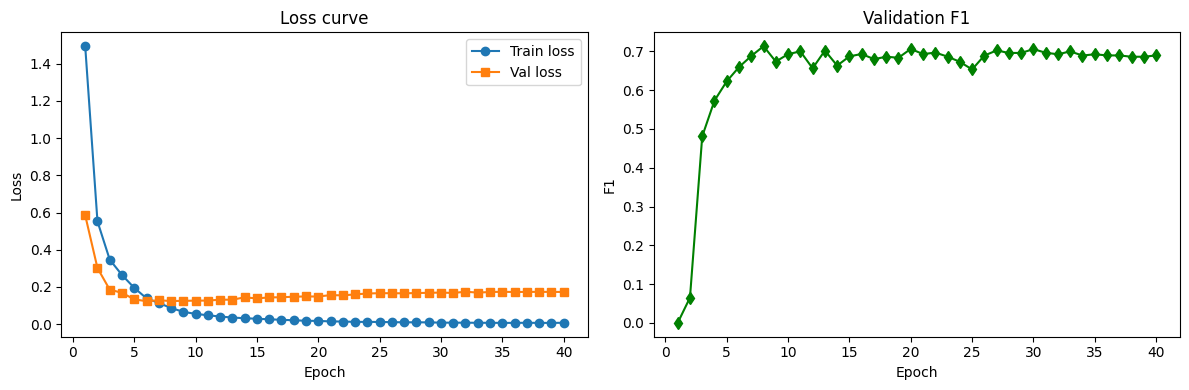

In [17]:
history = trainer.state.log_history
train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
eval_rows  = [h for h in history if "eval_loss" in h]

ep_t, l_t = zip(*train_loss)
ep_e   = [h["epoch"] for h in eval_rows]
l_e    = [h["eval_loss"] for h in eval_rows]
f1_e   = [h["eval_f1"] for h in eval_rows]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep_t, l_t, "o-", label="Train loss")
ax[0].plot(ep_e, l_e, "s-", label="Val loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss curve"); ax[0].legend()

ax[1].plot(ep_e, f1_e, "d-", color="green")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("F1"); ax[1].set_title("Validation F1")
plt.tight_layout(); plt.show()

In [18]:
test_metrics = trainer.evaluate(tokenized_ds["test"])
print("Test metrics:", test_metrics)

# Per-entity breakdown
preds, labels, _ = trainer.predict(tokenized_ds["test"])
preds = np.argmax(preds, axis=2)
true_preds = [[label_list[p] for p, l in zip(pred, lab) if l != -100]
              for pred, lab in zip(preds, labels)]
true_labels = [[label_list[l] for p, l in zip(pred, lab) if l != -100]
               for pred, lab in zip(preds, labels)]
print(seqeval.compute(predictions=true_preds, references=true_labels))

Test metrics: {'eval_loss': 0.1931031197309494, 'eval_precision': 0.6454545454545455, 'eval_recall': 0.7553191489361702, 'eval_f1': 0.6960784313725491, 'eval_accuracy': 0.9680150517403575, 'eval_runtime': 0.4192, 'eval_samples_per_second': 52.486, 'eval_steps_per_second': 4.771, 'epoch': 40.0}
{'Degree': {'precision': np.float64(0.75), 'recall': np.float64(0.75), 'f1': np.float64(0.75), 'number': np.int64(8)}, 'Designation': {'precision': np.float64(0.6470588235294118), 'recall': np.float64(0.6875), 'f1': np.float64(0.6666666666666667), 'number': np.int64(32)}, 'Location': {'precision': np.float64(0.6764705882352942), 'recall': np.float64(0.8214285714285714), 'f1': np.float64(0.7419354838709677), 'number': np.int64(28)}, 'Name': {'precision': np.float64(0.782608695652174), 'recall': np.float64(0.8181818181818182), 'f1': np.float64(0.8), 'number': np.int64(22)}, 'Skills': {'precision': np.float64(0.18181818181818182), 'recall': np.float64(0.5), 'f1': np.float64(0.26666666666666666), 'nu

In [19]:
from transformers import pipeline
ner = pipeline("ner", model=trainer.model, tokenizer=tokenizer, aggregation_strategy="simple")

sample = "John Smith worked at Google in California as a software engineer."
for ent in ner(sample):
    print(f"{ent['word']:20s} -> {ent['entity_group']}  ({ent['score']:.2f})")

John Smith           -> Name  (0.95)
